<img align="center" src="https://iili.io/3wI8gI.png" style="height:90px" style="width:30px"/>

# Part 1 | Beta distributions

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pymc as pm

## Q1 - Draw 10 000 samples from a Beta(1,1) distribution and save in a variable named `beta_weakest`

Use the beta function from numpy.random

In [2]:
beta_weakest = np.random.beta(1,1,10000)

### Q1.1 - Plot the distribution of `beta_weakest` 

<Axes: ylabel='Density'>

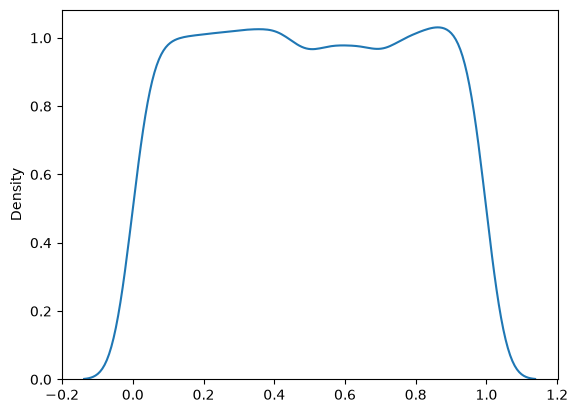

In [3]:
sns.kdeplot(beta_weakest)

## Q2 - Draw 10 000 samples from a Beta(10, 10) distribution and save in a variable named `beta_weak`


In [4]:
beta_weak = np.random.beta(10,10,10000)

### Q2.1 - Plot the distribution of `beta_weak` 

<Axes: ylabel='Density'>

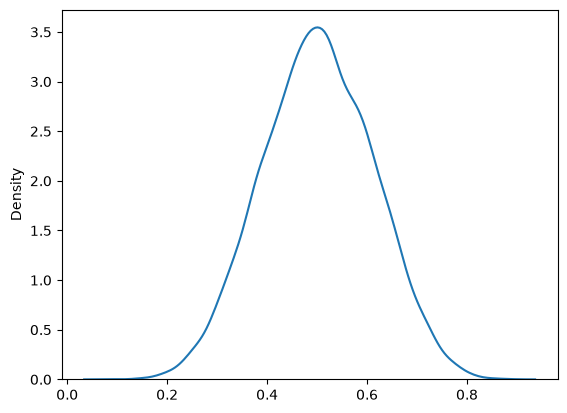

In [5]:
sns.kdeplot(beta_weak)

### Q2.2 - Calculate the 95% credible interval for `beta_weak`

import the pymc library and use the function pymc.stats.hdi

pass 0.95 to the hdi_prob parameter

In [9]:
pm.stats.hdi(beta_weak, prob = 0.95)

array([0.28655214, 0.71229881])

### Q2.3 - Explain the meaning of the 95% credible interval you just calculated for `beta_weak`
Answer this question in text

In [ ]:
# Answer: there is a 95% probability that the true value of beta weak is in this interval

## Q3 - Draw 10 000 samples from a Beta(100, 100) distribution and save in a variable named `beta_strong`

Use the beta function from numpy.random

In [10]:
beta_strong = np.random.beta(100,100,10000)

### Q3.1 - Plot the distribution of `beta_strong` 

<Axes: ylabel='Density'>

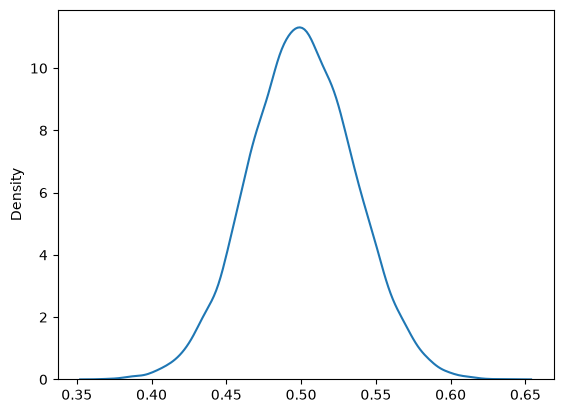

In [11]:
sns.kdeplot(beta_strong)

### Q3.2 - Calculate the 95% credible interval for `beta_strong`

In [12]:
pm.stats.hdi(beta_strong, prob = 0.95)

array([0.43133386, 0.56876504])

## Q4 - Plot `beta_weakest`, `beta_weak` & `beta_strong` on the same graph

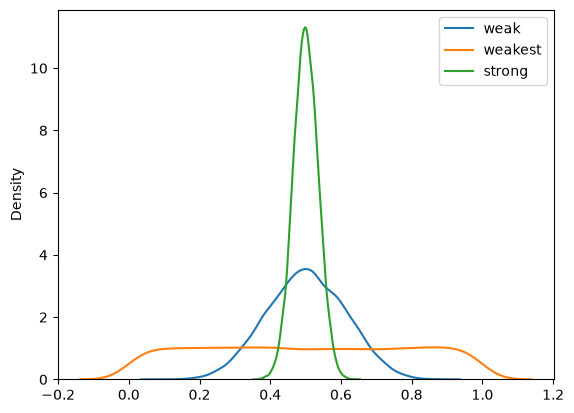

In [15]:
sns.kdeplot(beta_weak, label="weak")
sns.kdeplot(beta_weakest, label="weakest")
sns.kdeplot(beta_strong, label="strong")
plt.legend()
plt.show()

## Q5 - Draw 10 000 samples from a Beta(10, 40) distribution and save in a variable named `beta_1040`

In [16]:
beta_1040 = np.random.beta(10,40,10000)

### Q5.1 - Plot the distribution of `beta_1040` 

<Axes: ylabel='Density'>

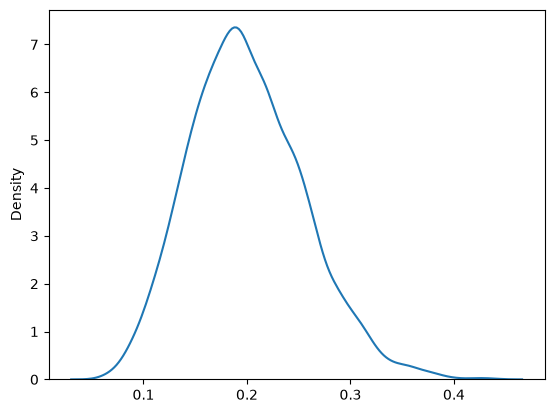

In [17]:
sns.kdeplot(beta_1040)

### Q5.2 - Calculate the 95% credible interval for `beta_1040`

In [18]:
pm.stats.hdi(beta_1040, prob = 0.95)

array([0.0983877 , 0.31120324])

## Q6 - Draw 10 000 samples from a Beta(227, 1552) distribution and save in a variable named `beta_227_1552`

In [19]:
beta_227_1552 = np.random.beta(227,1557,10000)

### Q6.1 - Plot the distribution of `beta_227_1552`

<Axes: ylabel='Density'>

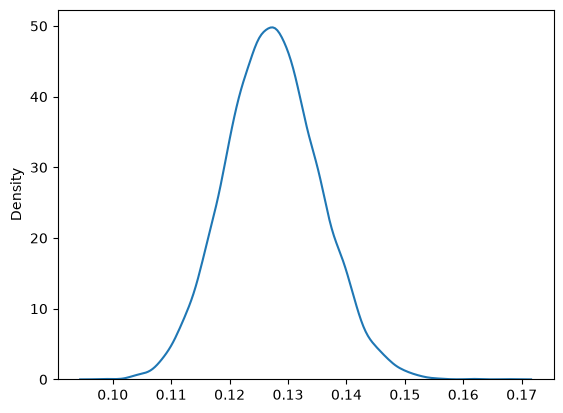

In [21]:
sns.kdeplot(beta_227_1552)

### Q6.2 - Calculate the 95% credible interval for `beta_227_1552`

In [22]:
pm.stats.hdi(beta_227_1552, prob= 0.95)

array([0.11177643, 0.14289178])

# Part 2 | Case: A/B test for conversion rates

The file `experiment_data_lab.csv` contains the result from our A/B test. Our metric/KPI is conversion rate which is referring to the proability that a customer will press a certain button.

Our goal now is to check if the treatment group had a significantly higher conversion rate

We have defined our prior belief for this A/B test to: 

- prior = beta(1,1)


## Q1 - Prepare the data

- 1) Read the file `experiment_data_lab.csv` and save in a variable named `df`


- 2) Calculate result from control
    - First calculate no. of conversions and save in a variable named `control_true`
    - Then calculate no. of non-conversions and save in a variable named `control_false`
    
    
- 3) Calculate result from treatment 
    - First calculate no. of conversions and save in a variable named `treatment_true`
    - Then calculate no. of non-conversions and save in a variable named `treatment_false`

In [23]:
import pandas as pd

In [24]:
df = pd.read_csv("experiment_data_lab.csv")

In [25]:
df.head()

,userId,group,converted
0,a5a178d8725240dda10680fde7be89ff,control,False
1,f7f0e56f44744114be2ff42911eb604f,treatment,False
2,36b4e919ed134c928d1915c5bf4e99e4,treatment,False
3,9b9608e6a4754c118bc2792c18bba0c6,treatment,False
4,dff2f271ba55486895c1669825945a64,control,False


## Q2 - Calculate posterior belief for control 

Draw 10 000 samples using the np.random.beta function from the following beta distribution:

```
beta(1 + control_true, 1 + control_false)
```

Save the sampled distribution in a variable name `control_posterior`

In [ ]:
control_true = df.loc[(df["group"] == "control") & (df["converted"])]
control_false = df.loc[(df["group"] == "control") & ~(df["converted"])]

control_post = np.random.beta(1 + len(control_true), 1 + len(control_false),10000)

### Q2.1 - Calculate the 95% credible interval for `control_posterior`

In [38]:
pm.stats.hdi(control_post, prob = 0.95)

array([0.09105878, 0.11753892])

## Q3 - Calculate posterior belief for treatment 

Draw 10 000 samples using the np.random.beta function from the following beta distribution:

```
beta(1 + treatment_true, 1 + treatment_false)
```

Save the sampled distribution in a variable name `treatment_posterior`

In [34]:
treatment_true = df.loc[(df["group"] == "treatment") & (df["converted"])]
treatment_false = df.loc[(df["group"] == "treatment") & ~(df["converted"])]

treatment_post = np.random.beta(1 + len(treatment_true), 1 + len(treatment_false),10000)


### Q3.1 - Calculate the 95% credible interval for `treatment_posterior`

In [35]:
pm.stats.hdi(treatment_post,prob = 0.95)

array([0.10980513, 0.1383336 ])

## Q4 - Plot `control_posterior` & `treatment_posterior` on the same graph

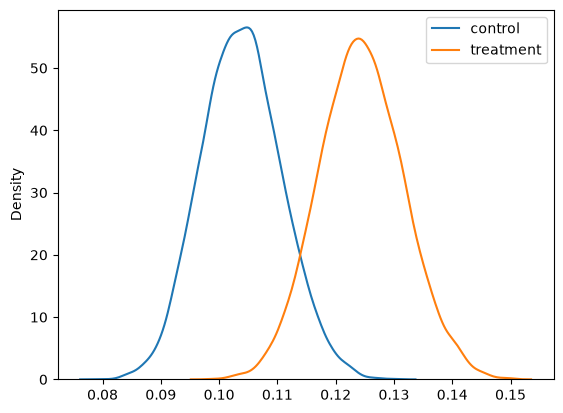

In [39]:
sns.kdeplot(control_post, label = "control")
sns.kdeplot(treatment_post, label = "treatment")
plt.legend()
plt.show()


## Q5 - Calculate probability of treatment being better than control

This can easily be done by:
- First, subtracting control_posterior from treatment_posterior (save this in a variable named `diff`)
- Then, calculate the percentage of times that the difference is less than 0

In [43]:
diff =  treatment_post - control_post

In [47]:
type(diff)


numpy.ndarray

In [48]:
(diff > 0).mean()*100 

np.float64(97.81)

In [50]:
diff.mean()

np.float64(0.02059186808762403)

## Q6 - Calculate a 95% credible interval for `diff`

In [49]:
pm.stats.hdi(diff, prob = 0.95)

array([0.0004703 , 0.03991655])

### Q6.1 - Explain the meaning of the 95% credible interval for `diff`

Answer this question in text

In [ ]:
# Answer: with 95% certainty the effect experiemnt has is inbetween this interval

## Q7 - Which version do you choose? 

Answer question in text. Briefly explain your choice

In [ ]:
# Answer: experiment has 2% effect so i would go with that given no drawbacks